In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [2]:
import os

base_path = r'C:\Users\Administrator\Desktop\Projects\Churn-Analysis\data'

df = pd.read_csv(os.path.join(base_path, 'WA_Fn-UseC_-Telco-Customer-Churn.csv'))

print("✅ Dataset loaded!")
print(f"Shape: {df.shape}")
print(f"\nFirst 5 rows:")
df.head()

✅ Dataset loaded!
Shape: (7043, 21)

First 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
print("=== DATASET INFO ===")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

print("\n=== COLUMN NAMES ===")
print(list(df.columns))

print("\n=== MISSING VALUES ===")
print(df.isnull().sum())

print("\n=== CHURN DISTRIBUTION ===")
print(df['Churn'].value_counts())
print(f"\nChurn Rate: {df['Churn'].value_counts(normalize=True)['Yes']*100:.1f}%")

=== DATASET INFO ===
Rows: 7043
Columns: 21

=== COLUMN NAMES ===
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

=== MISSING VALUES ===
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

=== CHURN DISTRIBUTION ===
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn Rate: 26.5%


In [4]:
# Fix TotalCharges — stored as text, convert to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Drop rows where TotalCharges couldn't convert (only 11 rows)
df = df.dropna(subset=['TotalCharges'])

# Convert Churn to binary safely
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Drop customerID only if it still exists
if 'customerID' in df.columns:
    df = df.drop('customerID', axis=1)

print("✅ Data cleaned!")
print(f"Final shape: {df.shape}")
print(f"Churn distribution: {df['Churn'].value_counts().to_dict()}")
print(f"TotalCharges dtype: {df['TotalCharges'].dtype}")
print(f"Churn dtype: {df['Churn'].dtype}")

✅ Data cleaned!
Final shape: (7032, 20)
Churn distribution: {0: 5163, 1: 1869}
TotalCharges dtype: float64
Churn dtype: int64


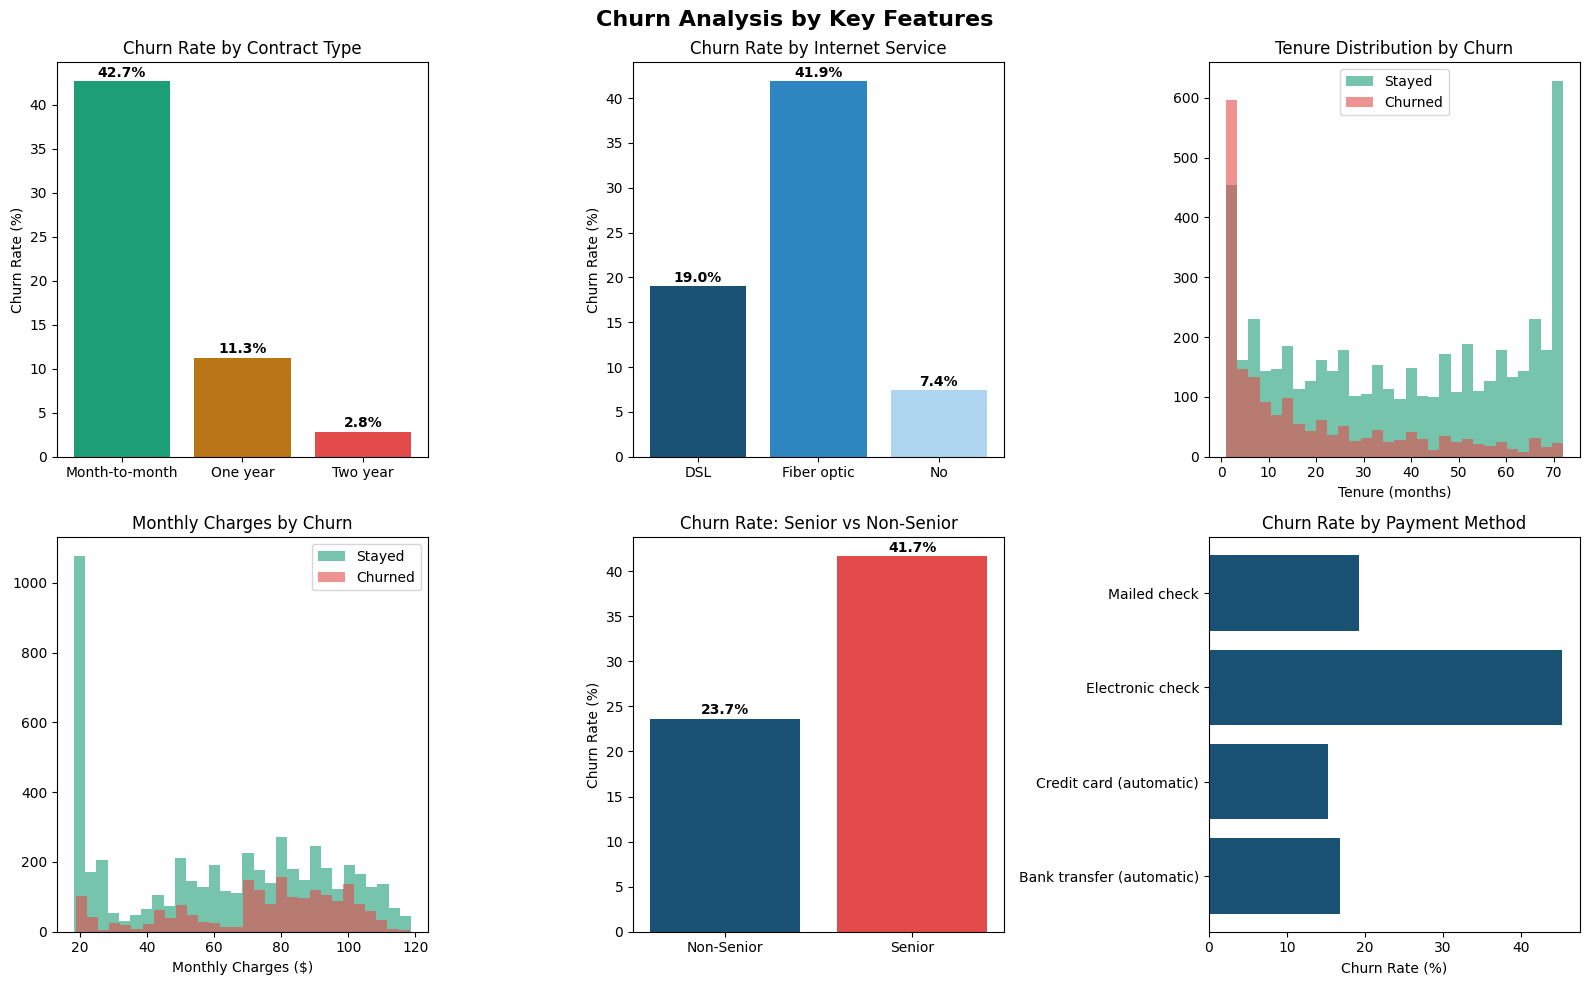


📊 KEY EDA FINDINGS:
Month-to-Month contract churn: 42.7%
Two Year contract churn:       2.8%
Fiber Optic churn rate:        41.9%
Senior citizen churn rate:     41.7%
Non-senior churn rate:         23.7%


In [5]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Churn Analysis by Key Features', fontsize=16, fontweight='bold')

# 1. Contract Type
contract_churn = df.groupby('Contract')['Churn'].mean() * 100
axes[0,0].bar(contract_churn.index, contract_churn.values, color=['#1D9E75','#BA7517','#E24B4A'])
axes[0,0].set_title('Churn Rate by Contract Type')
axes[0,0].set_ylabel('Churn Rate (%)')
for i, v in enumerate(contract_churn.values):
    axes[0,0].text(i, v+0.5, f'{v:.1f}%', ha='center', fontweight='bold')

# 2. Internet Service
internet_churn = df.groupby('InternetService')['Churn'].mean() * 100
axes[0,1].bar(internet_churn.index, internet_churn.values, color=['#1A5276','#2E86C1','#AED6F1'])
axes[0,1].set_title('Churn Rate by Internet Service')
axes[0,1].set_ylabel('Churn Rate (%)')
for i, v in enumerate(internet_churn.values):
    axes[0,1].text(i, v+0.5, f'{v:.1f}%', ha='center', fontweight='bold')

# 3. Tenure distribution
axes[0,2].hist(df[df['Churn']==0]['tenure'], bins=30, alpha=0.6, 
               color='#1D9E75', label='Stayed')
axes[0,2].hist(df[df['Churn']==1]['tenure'], bins=30, alpha=0.6, 
               color='#E24B4A', label='Churned')
axes[0,2].set_title('Tenure Distribution by Churn')
axes[0,2].set_xlabel('Tenure (months)')
axes[0,2].legend()

# 4. Monthly Charges
axes[1,0].hist(df[df['Churn']==0]['MonthlyCharges'], bins=30, alpha=0.6,
               color='#1D9E75', label='Stayed')
axes[1,0].hist(df[df['Churn']==1]['MonthlyCharges'], bins=30, alpha=0.6,
               color='#E24B4A', label='Churned')
axes[1,0].set_title('Monthly Charges by Churn')
axes[1,0].set_xlabel('Monthly Charges ($)')
axes[1,0].legend()

# 5. Senior Citizen
senior_churn = df.groupby('SeniorCitizen')['Churn'].mean() * 100
axes[1,1].bar(['Non-Senior', 'Senior'], senior_churn.values, 
               color=['#1A5276', '#E24B4A'])
axes[1,1].set_title('Churn Rate: Senior vs Non-Senior')
axes[1,1].set_ylabel('Churn Rate (%)')
for i, v in enumerate(senior_churn.values):
    axes[1,1].text(i, v+0.5, f'{v:.1f}%', ha='center', fontweight='bold')

# 6. Payment Method
payment_churn = df.groupby('PaymentMethod')['Churn'].mean() * 100
axes[1,2].barh(payment_churn.index, payment_churn.values, color='#1A5276')
axes[1,2].set_title('Churn Rate by Payment Method')
axes[1,2].set_xlabel('Churn Rate (%)')

plt.tight_layout()
plt.savefig(r'C:\Users\Administrator\Desktop\Projects\Churn-Analysis\notebooks\eda_charts.png', dpi=150)
plt.show()

print("\n📊 KEY EDA FINDINGS:")
print(f"Month-to-Month contract churn: {contract_churn['Month-to-month']:.1f}%")
print(f"Two Year contract churn:       {contract_churn['Two year']:.1f}%")
print(f"Fiber Optic churn rate:        {internet_churn['Fiber optic']:.1f}%")
print(f"Senior citizen churn rate:     {senior_churn[1]:.1f}%")
print(f"Non-senior churn rate:         {senior_churn[0]:.1f}%")

In [7]:
# Separate categorical and numerical columns
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f"Categorical columns to encode: {cat_cols}")

# Label encode all categorical columns
le = LabelEncoder()
df_encoded = df.copy()

for col in cat_cols:
    df_encoded[col] = le.fit_transform(df[col])

print("\n✅ Encoding complete!")
print(f"Shape after encoding: {df_encoded.shape}")
print(f"\nSample encoded values:")
print(df_encoded.head(3))

Categorical columns to encode: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

✅ Encoding complete!
Shape after encoding: (7032, 20)

Sample encoded values:
   gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
0       0              0        1           0       1             0   
1       1              0        0           0      34             1   
2       1              0        0           0       2             1   

   MultipleLines  InternetService  OnlineSecurity  OnlineBackup  \
0              1                0               0             2   
1              0                0               2             0   
2              0                0               2             2   

   DeviceProtection  TechSupport  StreamingTV  StreamingMovies  Contract  \
0                 0 

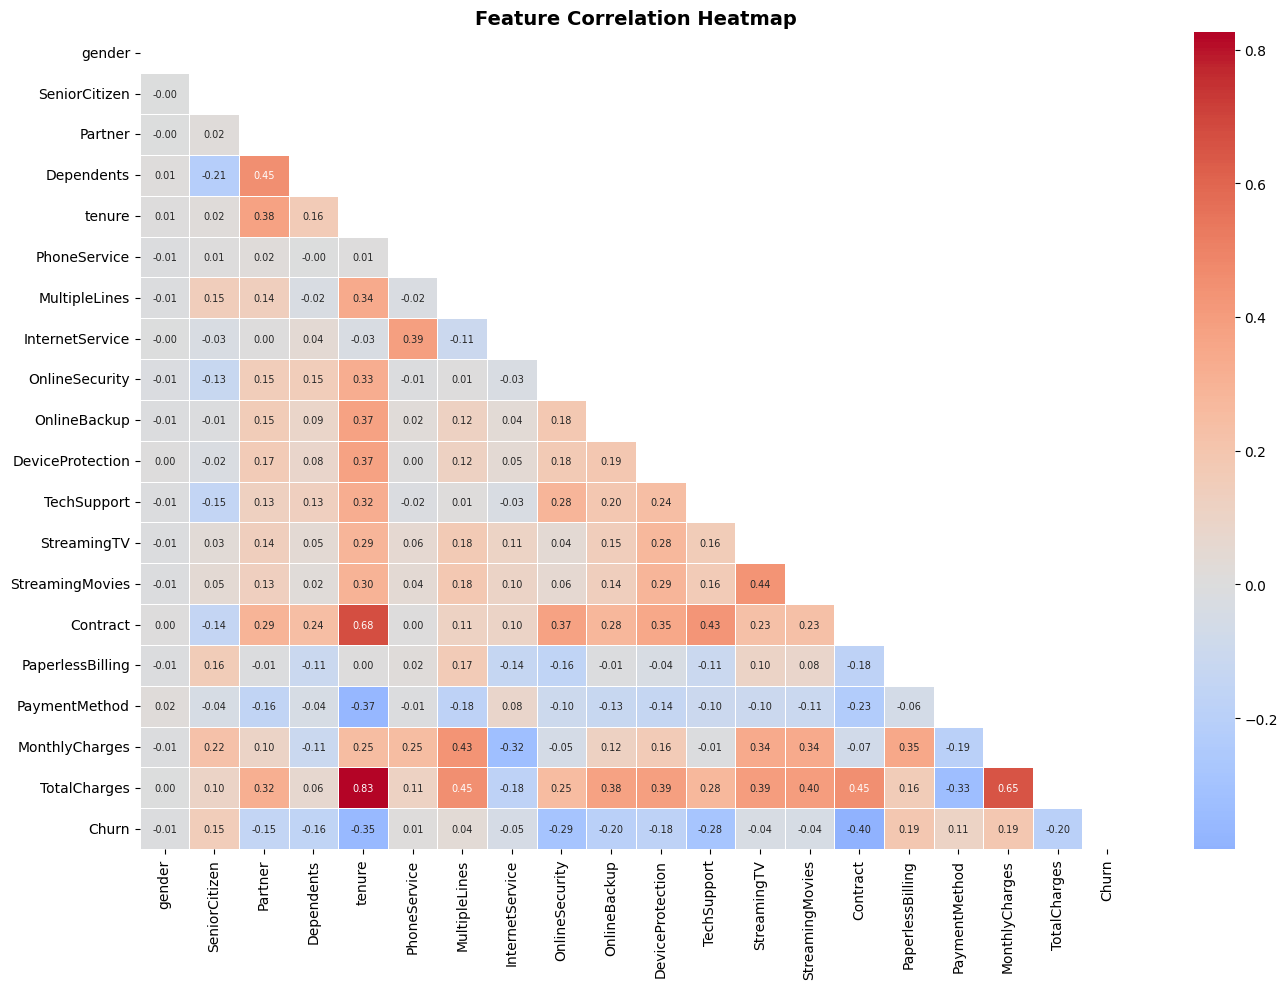


🔥 Top 5 features correlated with Churn:
   Contract: -0.396
   tenure: -0.354
   OnlineSecurity: -0.289
   TechSupport: -0.282
   TotalCharges: -0.199


In [9]:
plt.figure(figsize=(14, 10))
correlation = df_encoded.corr()
mask = np.triu(np.ones_like(correlation, dtype=bool))

sns.heatmap(correlation, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5,
            annot_kws={'size': 7})

plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(r'C:\Users\Administrator\Desktop\Projects\Churn-Analysis\notebooks\correlation_heatmap.png', dpi=150)
plt.show()

# Top features correlated with Churn
churn_corr = correlation['Churn'].drop('Churn').sort_values(key=abs, ascending=False)
print("\n🔥 Top 5 features correlated with Churn:")
for feat, val in churn_corr.head(5).items():
    print(f"   {feat}: {val:.3f}")

In [10]:
# Features and target
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

print(f"Features shape: {X.shape}")
print(f"Target shape:   {y.shape}")
print(f"Class balance before SMOTE: {y.value_counts().to_dict()}")

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTrain size: {X_train.shape[0]}")
print(f"Test size:  {X_test.shape[0]}")

# Apply SMOTE to balance classes
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"\n✅ SMOTE applied!")
print(f"Class balance after SMOTE: {pd.Series(y_train_sm).value_counts().to_dict()}")

Features shape: (7032, 19)
Target shape:   (7032,)
Class balance before SMOTE: {0: 5163, 1: 1869}

Train size: 5625
Test size:  1407

✅ SMOTE applied!
Class balance after SMOTE: {0: 4130, 1: 4130}
